In [1]:
##############
## INITIATE ##
##############

## Imports
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

#
###

In [2]:
###########################
## SCRIPT CONFIGURATIONS ##
###########################

## Define paths to embeddings
pti = '/Users/user/Documents/projects/GlandSeg/outputs/V2_0_0_20250120/o2_embeddings/tcga_ffpes/model_resnet_tcga_raw_FTL_0/'
embeddings_path = pti + 'embeddings.npy'
identifiers_path = pti + 'image_identifiers.csv'

## Define paths to images
dataset_path = '/Users/user/Documents/projects/GlandSeg/outputs/V2_0_0_20250120/o1_extracted_glands/tcga_ffpes_V1'
# dataset_path = '/Users/user/Documents/projects/GlandSeg/outputs/V2_0_0_20250120/o1_extracted_glands/debug'

#
###

In [3]:
######################
## LOAD EMBEDDINGS  ##
######################

## Load the embeddings from the .npy file
embeddings = np.load(embeddings_path)

## Load identifiers
identifiers_df = pd.read_csv(identifiers_path)
image_filenames = identifiers_df['filename'].tolist()

## Check the shape of the loaded embeddings and identifiers
print(f'Loaded embeddings shape: {embeddings.shape}')
print(f'Loaded {len(image_filenames)} image identifiers')

#
###

Loaded embeddings shape: (23415, 512)
Loaded 23415 image identifiers


In [4]:
#######################
## FORMAT IDENTIFIER ##
#######################

## Get unique identifiers
# split_marker = '_'
# image_filenames_short = [fname.split(split_marker)[1] for fname in image_filenames]
split_marker = '-01' # For TCGA
image_filenames_short = [fname.split(split_marker)[0] for fname in image_filenames] # For TCGA
unique_ids = np.unique(image_filenames_short)
num_groups = len(unique_ids)
print(num_groups)

numeric_ids = np.zeros(len(image_filenames_short))
k = 0
for unique_id in unique_ids:    
    index = np.argwhere(np.array(image_filenames_short) == unique_id)
    numeric_ids[index] = k
    k += 1

#
###

10


In [5]:
"""
##########################
## APPLY PCA REDUCTION ##
##########################

## Local imports
from sklearn.decomposition import PCA

## PCA parameters
n_components = 32  ## Set to 3 for 3D visualization

## Initialize PCA reducer
pca_reducer = PCA(n_components=n_components)

## Fit and transform the embeddings
embeddings = pca_reducer.fit_transform(embeddings)

## Check the shape of the reduced embeddings
print(f'Reduced embeddings shape: {embeddings.shape}')

#
###
"""

"\n##########################\n## APPLY PCA REDUCTION ##\n##########################\n\n## Local imports\nfrom sklearn.decomposition import PCA\n\n## PCA parameters\nn_components = 32  ## Set to 3 for 3D visualization\n\n## Initialize PCA reducer\npca_reducer = PCA(n_components=n_components)\n\n## Fit and transform the embeddings\nembeddings = pca_reducer.fit_transform(embeddings)\n\n## Check the shape of the reduced embeddings\nprint(f'Reduced embeddings shape: {embeddings.shape}')\n\n#\n###\n"

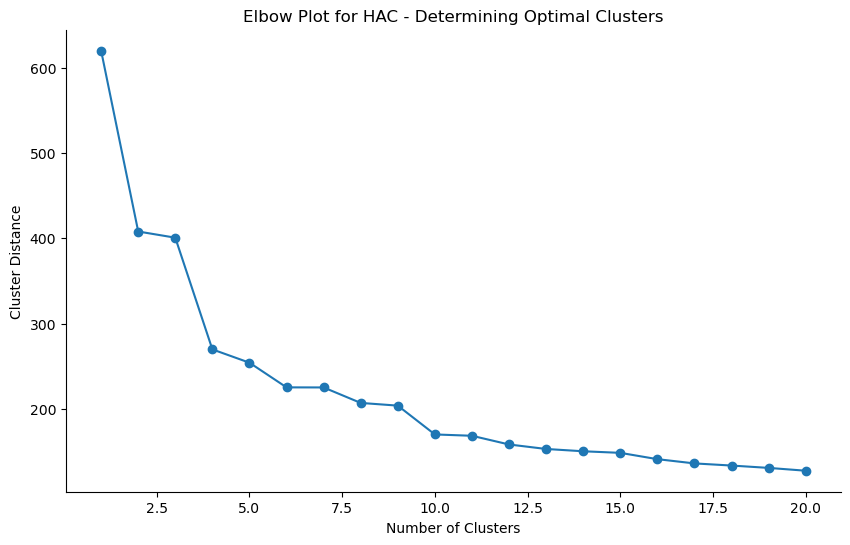

In [5]:
###############################
## PERFORM HAC ON EMBEDDINGS ##
###############################

## Perform hierarchical agglomerative clustering (HAC) on the high-dimensional embeddings
linkage_matrix = linkage(embeddings, method='ward')  ## Using Ward's method for clustering

## Elbow plot to determine the optimal number of clusters
last = linkage_matrix[-20:, 2]
last_rev = last[::-1]
idxs = np.arange(1, len(last) + 1)
plt.figure(figsize=(10, 6))
plt.plot(idxs, last_rev, marker="o")
plt.title('Elbow Plot for HAC - Determining Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Cluster Distance')
plt.grid(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

#
###

In [6]:
#######################################
## SELECT OPTIMAL NUMBER OF CLUSTERS ##
#######################################

## HAC parameters
num_clusters = 10  ## Set to the optimal number of clusters identified earlier

## Assign cluster labels based on the specified number of clusters
cluster_labels = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

## Check the result
print(f'Cluster labels assigned to {len(cluster_labels)} images')

#
###

Cluster labels assigned to 23415 images


In [7]:
#########################################
## SAVE EMBEDDINGS AND CLUSTER LABELS  ##
#########################################

## Create a dataframe to store the embeddings and their corresponding cluster labels
clustered_data = pd.DataFrame({
    'filename': image_filenames,
    'cluster_label': cluster_labels
})

## Save the cluster labels to a CSV file
output_path = pti + 'clustered_embeddings.csv'  ## Replace with your desired output path
clustered_data.to_csv(output_path, index=False)

## End
print(f'Clustered data saved to {output_path}')

#
###

Clustered data saved to /Users/user/Documents/projects/GlandSeg/outputs/V2_0_0_20250120/o2_embeddings/tcga_ffpes/model_resnet_tcga_raw_FTL_0/clustered_embeddings.csv


In [8]:
###########################
## APPLY t-SNE REDUCTION ##
###########################

## Local imports
from sklearn.manifold import TSNE

## t-SNE parameters
n_components = 2  ## Set to 3 for 3D visualization
perplexity = 30  # Similar to UMAP's n_neighbors
learning_rate = 200  # Default recommended learning rate
random_state = 42

## Initialize t-SNE reducer
tsne_reducer = TSNE(n_components=n_components, perplexity=perplexity, learning_rate=learning_rate, random_state=random_state)

## Fit and transform the embeddings
reduced_embeddings = tsne_reducer.fit_transform(embeddings)

## Check the shape of the reduced embeddings
print(f'Reduced embeddings shape: {reduced_embeddings.shape}')

#
###

Reduced embeddings shape: (23415, 2)


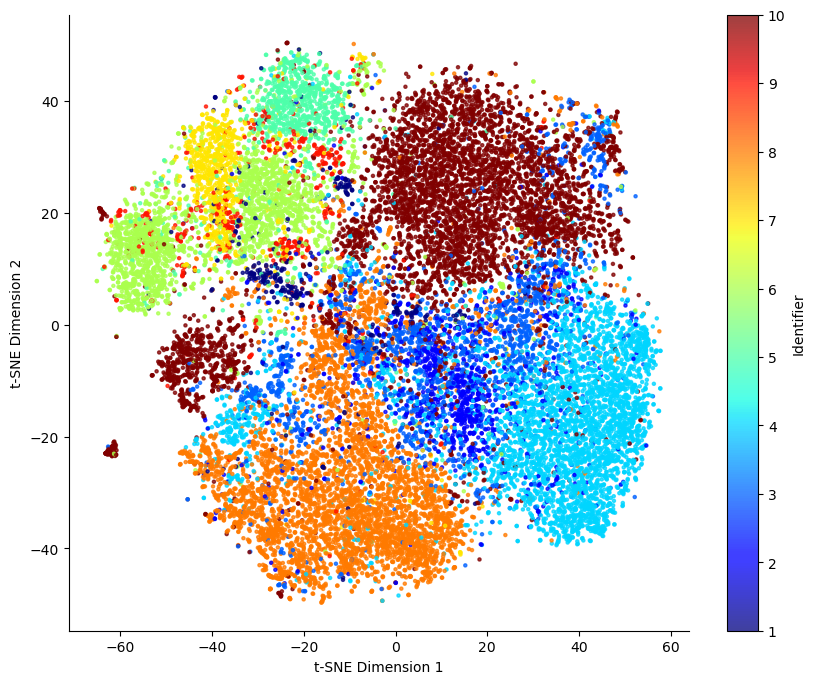

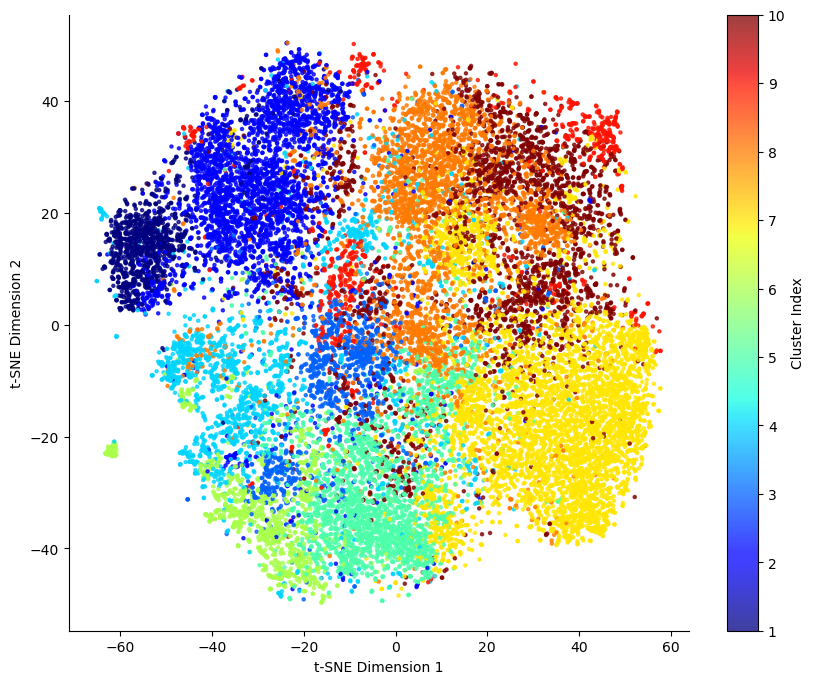

In [9]:
##############################################
## UPDATE t-SNE VISUALIZATION WITH CLUSTERS ##
##############################################

## 2D Visualization with clusters
if n_components == 2:

    ## t-SNE with ID
    plt.figure(figsize=(10, 8))    
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                          c=numeric_ids + 1, cmap='jet', s=5, alpha=0.75)    
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(False)
    plt.colorbar(scatter, ticks=range(1, num_groups + 1), label='Identifier')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()

    ## t-SNE with cluster index
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                          c=cluster_labels, cmap='jet', s=5, alpha=0.75)    
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(False)
    plt.colorbar(scatter, ticks=range(1, num_clusters + 1), label='Cluster Index')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()

#
###

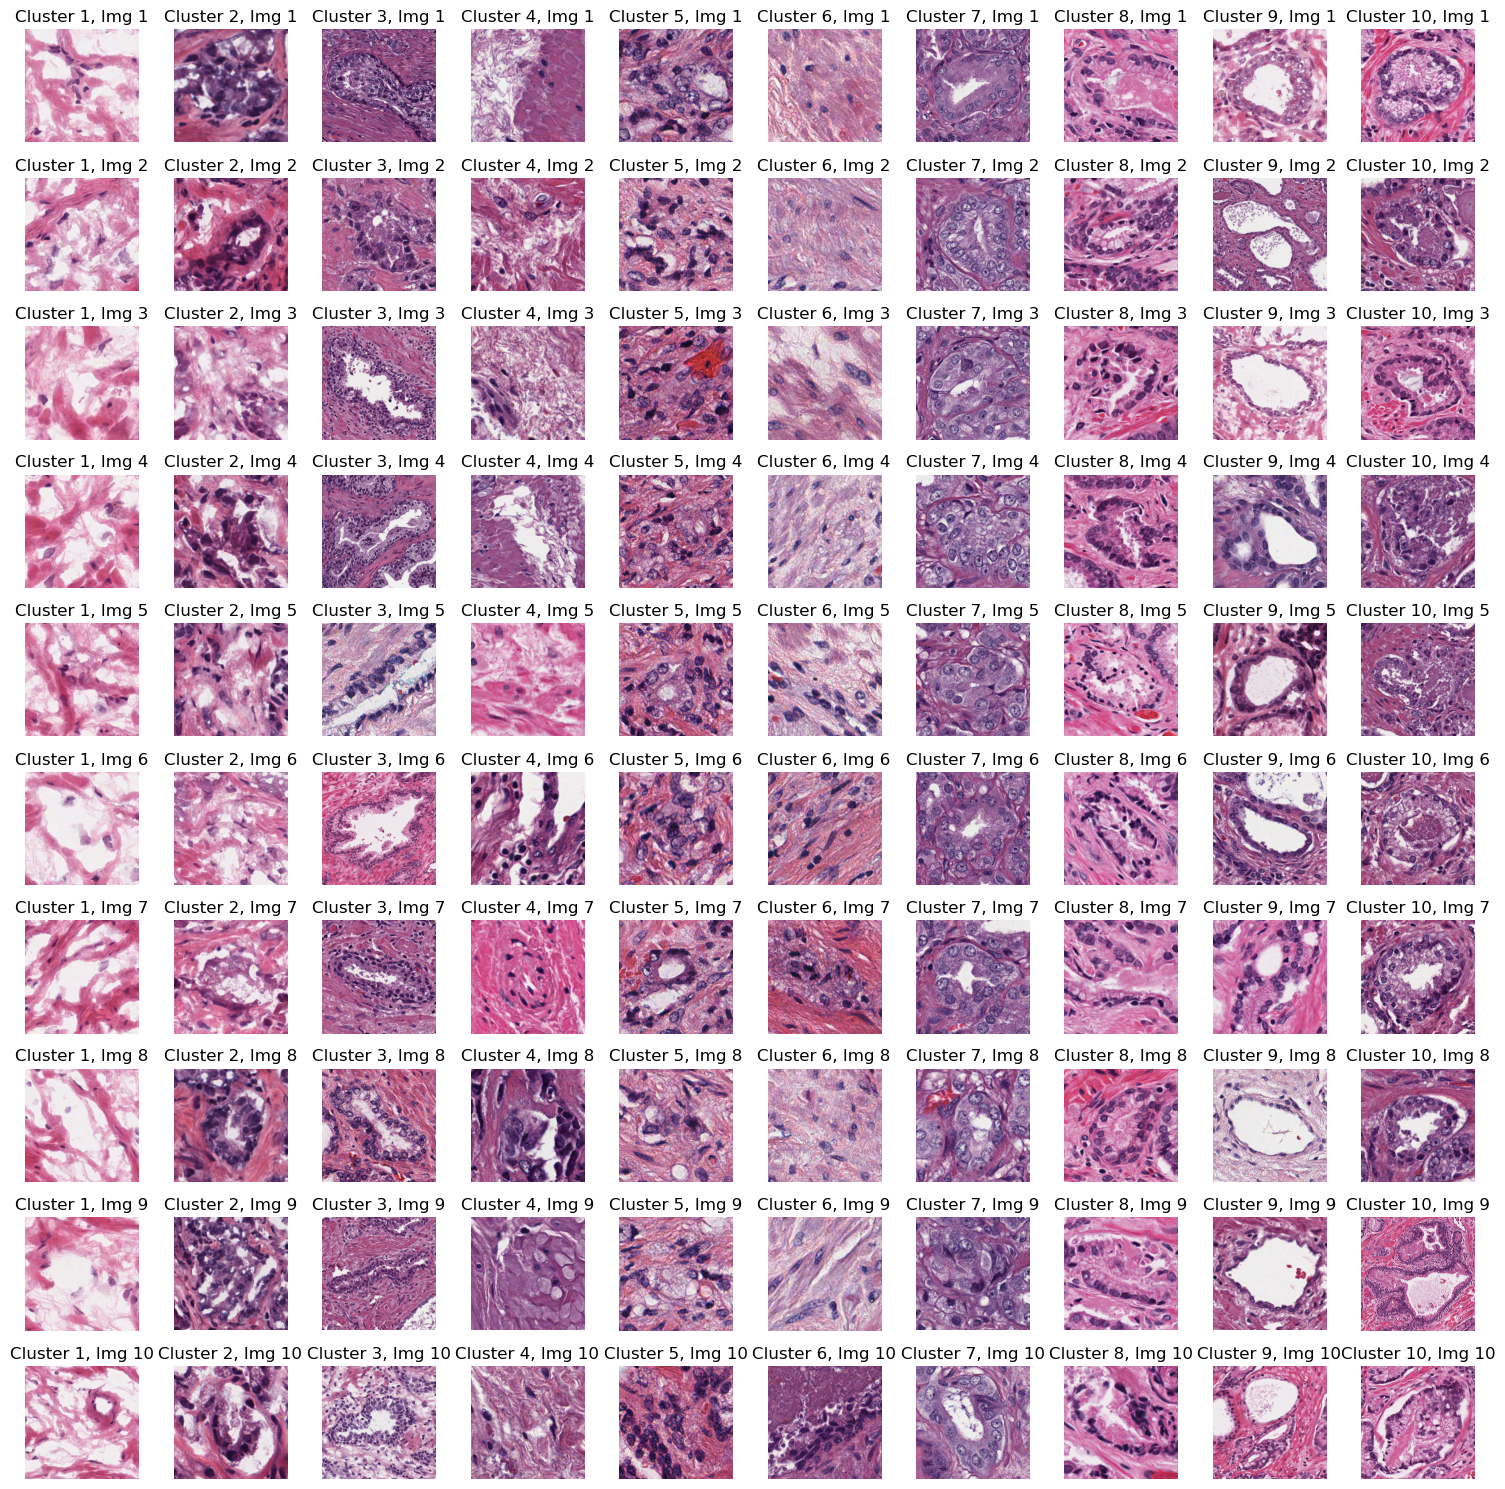

In [10]:
##########################################
## PICK AND SHOW EXAMPLES FROM CLUSTERS ##
##########################################

examples_per_cluster = 10  ## Number of examples to show per cluster

## Initialize figure for examples
fig, axs = plt.subplots(examples_per_cluster, num_clusters, figsize=(15, 15))

## Compute cluster centroids
cluster_centroids = []
for cluster_idx in range(1, num_clusters + 1):
    cluster_embeddings = [embeddings[i] for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_idx]
    cluster_centroid = np.mean(cluster_embeddings, axis=0)
    cluster_centroids.append(cluster_centroid)

## Loop over clusters
for cluster_idx in range(1, num_clusters + 1):
    
    ## Get all indices in the current cluster
    cluster_indices = [i for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_idx]
    cluster_files = [image_filenames[i] for i in cluster_indices]
    cluster_embeddings = [embeddings[i] for i in cluster_indices]
    
    ## Compute distances to centroid
    distances = pairwise_distances(cluster_embeddings, [cluster_centroids[cluster_idx - 1]])
    closest_indices = np.argsort(distances[:, 0])[:examples_per_cluster]
    selected_files = np.array(cluster_files)[closest_indices]

    ## Load and display each example
    for example_idx, filename in enumerate(selected_files):
        image_path = f'{dataset_path}/{filename}'
        image_path = image_path.replace('_mask_both','_raw')
        image = Image.open(image_path)
        #
        axs[example_idx, cluster_idx - 1].imshow(image)
        axs[example_idx, cluster_idx - 1].axis('off')
        axs[example_idx, cluster_idx - 1].set_title(f'Cluster {cluster_idx}, Img {example_idx + 1}')

plt.tight_layout()
plt.show()

#
###

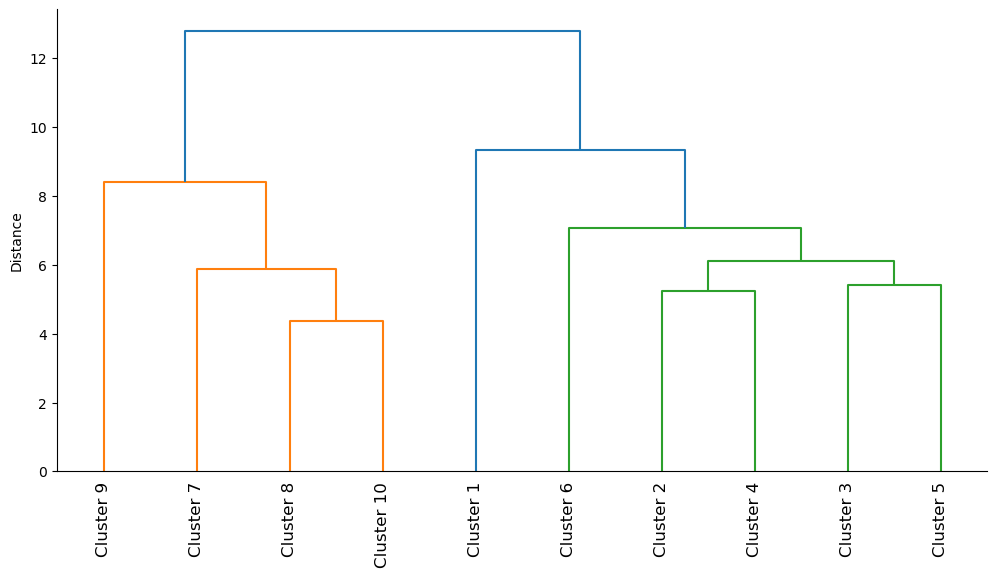

In [11]:
######################################
## VISUALIZE DENDROGRAM OF CLUSTERS ##
######################################

from scipy.cluster.hierarchy import dendrogram

## Compute linkage matrix for hierarchical clustering
linkage_matrix = linkage(cluster_centroids, method='ward')

## Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=[f'Cluster {i+1}' for i in range(num_clusters)], leaf_rotation=90, leaf_font_size=12)
# plt.title('Hierarchical Clustering Dendrogram')
# plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

#
###

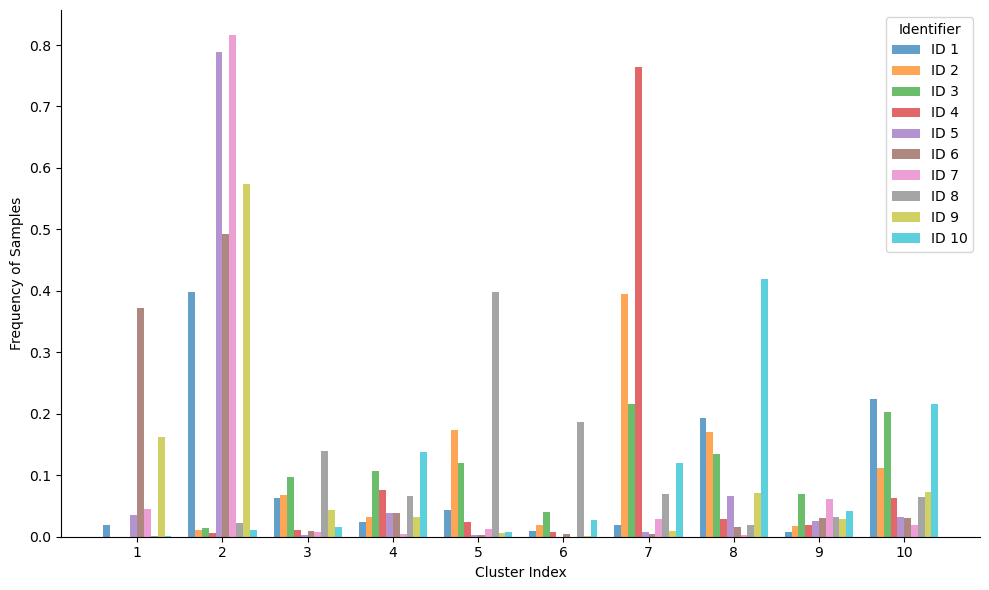

In [12]:
##########################
## CLUSTER DISTRIBUTION ##
##########################

## Convert to a DataFrame for easier manipulation
data = pd.DataFrame({
    'Cluster': cluster_labels,
    'Identifier': numeric_ids
})

## Get the unique clusters and identifiers
unique_clusters = sorted(data['Cluster'].unique())
unique_identifiers = sorted(data['Identifier'].unique())

## Count the frequency of clusters for each identifier
frequency_table = data.groupby(['Identifier', 'Cluster']).size().unstack(fill_value=0)

## Normalize the frequencies if needed (e.g., proportions instead of counts)
frequency_table = frequency_table.div(frequency_table.sum(axis=1), axis=0)

## Define an offset for each identifier
bar_width = 0.8 / len(unique_identifiers)  # Divide bar width among identifiers
x_offsets = np.linspace(-bar_width * (len(unique_identifiers) - 1) / 2, 
                        bar_width * (len(unique_identifiers) - 1) / 2, 
                        len(unique_identifiers))

## Plot the offset barplot
plt.figure(figsize=(10, 6))

for idx, identifier in enumerate(unique_identifiers):
    frequencies = frequency_table.loc[identifier]
    plt.bar(
        np.array(unique_clusters) + x_offsets[idx],  # Offset x positions
        frequencies,
        width=bar_width,  # Narrower bars to accommodate offsets
        alpha=0.7,  # Transparency for overlay
        label=f'ID {identifier + 1:.0f}'
    )

# Add labels, legend, and title
plt.xlabel('Cluster Index')
plt.ylabel('Frequency of Samples')
# plt.title('Cluster Frequency per Identifier')
plt.xticks(unique_clusters)  # Ensure all clusters are shown on the x-axis
plt.legend(title='Identifier')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#
###

In [13]:
###############################
## FUNCTIONS FOR PHENOTYPING ##
###############################

def binarise_image(image, thresholds=[30,30,30]):
    """
    Binarise image based on threshold for each channels.
    """
    for i in range(3):
        image[:,:,i] = (image[:,:,i] > thresholds[i])
    return image

def isolate_focal_gland(epithelial_prob, lumen_prob, threshold=0.5):
    """
    Isolates the focal gland in an image based on epithelial and luminal probability maps.
    """
    ## Step 1: Binarize the probability maps
    epithelial_mask = (epithelial_prob >= threshold).astype(np.uint8)
    lumen_mask = (lumen_prob >= threshold).astype(np.uint8)
    
    ## Step 2: Combine the binary masks to create a gland mask
    gland_mask = np.logical_or(epithelial_mask, lumen_mask).astype(np.uint8)
    
    # Step 3: Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(gland_mask, connectivity=8)
    
    ## Step 4: Identify the connected component containing the image center
    H, W = gland_mask.shape
    center_x, center_y = W // 2, H // 2
    
    focal_label = None
    for label in range(1, num_labels):  # Skipping background label (0)
        x, y, w, h, area = stats[label]
        if x <= center_x < x + w and y <= center_y < y + h:
            focal_label = label
            break
    
    if focal_label is not None:
        ## Step 5: Generate the final gland mask
        focal_gland_mask = (labels == focal_label).astype(np.uint8)
    else:
        ## If no gland is found at the center, return an empty mask
        focal_gland_mask = np.zeros_like(gland_mask, dtype=np.uint8)
    
    return focal_gland_mask

def compute_features(image, gland_mask):
    """
    Computes relative area and shape analysis features from the given binarized image and gland mask.
    """
    features = {}
    H, W = image.shape[:2]
    total_pixels = H * W
    
    nuclei_mask = image[:,:,0]
    epithelial_mask = image[:,:,1]
    lumen_mask = (1 - gland_mask) * epithelial_mask # image[:,:,2]

    # features['area'] = np.sum(gland_mask)
    
    ## Compute relative area features    
    features['relative_area_nuclei'] = np.sum(nuclei_mask) / total_pixels
    features['relative_area_epithelia'] = np.sum(epithelial_mask) / total_pixels
    features['relative_area_lumen'] = np.sum(lumen_mask) / total_pixels
    features['relative_area_epithelial_nuclei'] = np.sum(nuclei_mask * epithelial_mask) / total_pixels
    features['relative_area_non_epithelial_nuclei'] = np.sum(nuclei_mask * (1 - gland_mask)) / total_pixels
    
    ## Shape analysis features
    gland_contours, _ = cv2.findContours(gland_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if gland_contours:
        cnt = max(gland_contours, key=cv2.contourArea)        
        # features['area'] = cv2.contourArea(cnt)
        features['perimeter'] = cv2.arcLength(cnt, True)        
        # hull = cv2.convexHull(cnt)
        # features['convex_hull_area'] = cv2.contourArea(hull)
        # features['compactness'] = features['area'] / features['convex_hull_area'] if features['convex_hull_area'] > 0 else 0        
        # features['roundness'] = (4 * np.pi * features['area']) / (features['perimeter']**2) if features['perimeter'] > 0 else 0
    else:
        features.update({# 'area': 0, 
                         'perimeter': 0, 
                         # 'convex_hull_area': 0, 
                         # 'compactness': 0,
                         # 'roundness': 0,
        })
    
    return features

#
###

In [14]:
########################
## PHENOTYPE CLUSTERS ##
########################

## Initialize storage for features
examples_per_cluster = 100  ## Number of examples to show per cluster
cluster_feature_data = []

## Compute cluster centroids
cluster_centroids = []
for cluster_idx in range(1, num_clusters + 1):
    cluster_embeddings = [embeddings[i] for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_idx]
    cluster_centroid = np.mean(cluster_embeddings, axis=0)
    cluster_centroids.append(cluster_centroid)

## Loop over clusters
for cluster_idx in range(1, num_clusters + 1):
    
    ## Get all indices in the current cluster
    cluster_indices = [i for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_idx]
    cluster_files = [image_filenames[i] for i in cluster_indices]
    cluster_embeddings = [embeddings[i] for i in cluster_indices]
    
    ## Compute distances to centroid
    distances = pairwise_distances(cluster_embeddings, [cluster_centroids[cluster_idx - 1]])
    closest_indices = np.argsort(distances[:, 0])[:examples_per_cluster]
    selected_files = np.array(cluster_files)[closest_indices]
    
    ## Process each selected image
    for filename in selected_files:
        image_path = f'{dataset_path}/{filename}'
        image = np.array(Image.open(image_path))
        
        ## Binarize image
        image = binarise_image(image)
        
        ## Get gland mask
        mask = isolate_focal_gland(image[:,:,0], image[:,:,1])
        
        ## Compute features
        features = compute_features(image, mask)
        features['cluster'] = cluster_idx  # Assign cluster label
        cluster_feature_data.append(features)

# Convert feature data to DataFrame
feature_df = pd.DataFrame(cluster_feature_data)

#
###

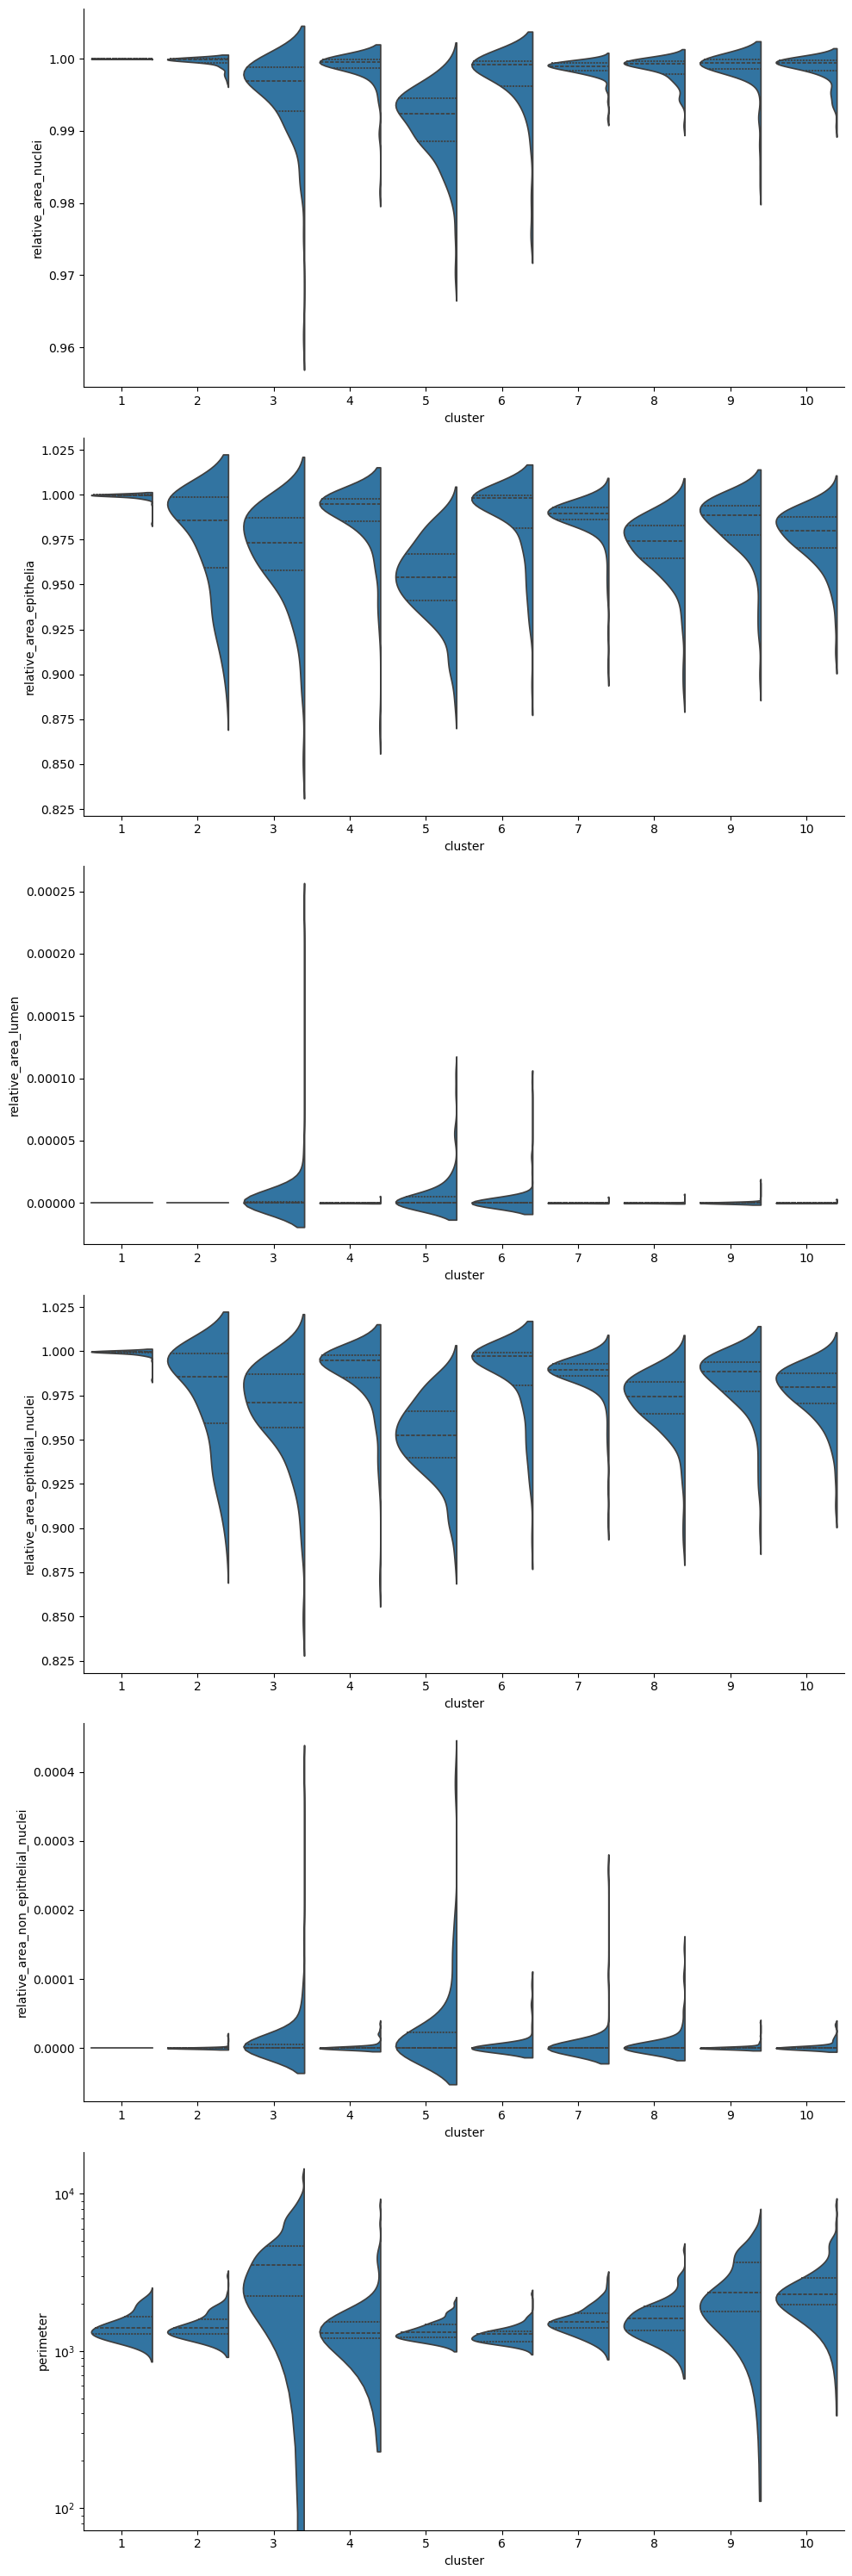

In [15]:
####################################
## VISUALISE FEATURE DISTRIBUTION ##
####################################

# Plot feature distributions for each cluster using violin plots
feature_names = feature_df.columns[:-1]  # Exclude 'cluster' column
num_features = len(feature_names)
fig, axs = plt.subplots(nrows=num_features, ncols=1, figsize=(10, 5 * num_features))
#
for i, feature in enumerate(feature_names):
    ax = axs[i]
    sns.violinplot(x='cluster', y=feature, data=feature_df, ax=ax, inner='quartile', density_norm='width', split=True)
    # ax.set_title(feature)
    if (feature == 'area') | (feature == 'perimeter') | (feature == 'convex_hull_area'):
        ax.set(yscale="log")
    #
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
#
plt.tight_layout()
plt.show()

#
###

In [279]:
"""
#######################
## FILTER EMBEDDINGS ##
#######################

## Remove files from data
index = np.argwhere((cluster_labels != 5) & (cluster_labels != 6)).flatten()
embeddings = embeddings[index]
reduced_embeddings = reduced_embeddings[index]
cluster_labels = cluster_labels[index]
numeric_ids = numeric_ids[index]
image_filenames = np.array(image_filenames)[index]

#
###
"""

In [16]:
"""
######################
## PHENOTYPE GLANDS ##
######################

## Load image
image_path = f'{dataset_path}/{image_filenames[10]}'
image = np.array(Image.open(image_path))

## Binarise image
image = binarise_image(image)

## Get mask
mask = isolate_focal_gland(image[:,:,0], image[:,:,1])

## Visualise
plt.imshow(image * 255 * mask[:,:,None])

## Compute features
features = compute_features(image, mask)
print(features)

#
###
"""

"\n######################\n## PHENOTYPE GLANDS ##\n######################\n\n## Load image\nimage_path = f'{dataset_path}/{image_filenames[10]}'\nimage = np.array(Image.open(image_path))\n\n## Binarise image\nimage = binarise_image(image)\n\n## Get mask\nmask = isolate_focal_gland(image[:,:,0], image[:,:,1])\n\n## Visualise\nplt.imshow(image * 255 * mask[:,:,None])\n\n## Compute features\nfeatures = compute_features(image, mask)\nprint(features)\n\n#\n###\n"

In [17]:
"""
##########################################
## PICK AND SHOW EXAMPLES FROM CLUSTERS ##
##########################################

## Initialize figure for examples
fig, axs = plt.subplots(examples_per_cluster, num_clusters, figsize=(15, 15))

## Loop over clusters
for cluster_idx in range(1, num_clusters + 1):
    
    ## Get all filenames in the current cluster
    cluster_files = [image_filenames[i] for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_idx]
    
    ## Select a few examples from the cluster
    s = np.random.choice(len(cluster_files), examples_per_cluster, replace=False)
    selected_files = np.array(cluster_files)[s]
    # selected_files = cluster_files[:examples_per_cluster]  ## Adjust if there are fewer files    

    ## Load and display each example
    for example_idx, filename in enumerate(selected_files):
        image_path = f'{dataset_path}/{filename}'
        image = Image.open(image_path)
        axs[example_idx, cluster_idx - 1].imshow(image)
        axs[example_idx, cluster_idx - 1].axis('off')
        axs[example_idx, cluster_idx - 1].set_title(f'Cluster {cluster_idx}, Img {example_idx + 1}')

plt.tight_layout()
plt.show()

#
###
"""

"\n##########################################\n## PICK AND SHOW EXAMPLES FROM CLUSTERS ##\n##########################################\n\n## Initialize figure for examples\nfig, axs = plt.subplots(examples_per_cluster, num_clusters, figsize=(15, 15))\n\n## Loop over clusters\nfor cluster_idx in range(1, num_clusters + 1):\n    \n    ## Get all filenames in the current cluster\n    cluster_files = [image_filenames[i] for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_idx]\n    \n    ## Select a few examples from the cluster\n    s = np.random.choice(len(cluster_files), examples_per_cluster, replace=False)\n    selected_files = np.array(cluster_files)[s]\n    # selected_files = cluster_files[:examples_per_cluster]  ## Adjust if there are fewer files    \n\n    ## Load and display each example\n    for example_idx, filename in enumerate(selected_files):\n        image_path = f'{dataset_path}/{filename}'\n        image = Image.open(image_path)\n        axs[example_idx, clus

In [261]:
"""
##########################
## APPLY UMAP REDUCTION ##
##########################

## Local imports
import umap

## UMAP parameters
n_neighbors = 30 // 2
min_dist = 0.1 // 2
n_components = 2  ## Set to 3 for 3D visualization

## Initialize UMAP reducer
umap_reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, random_state=42)

## Fit and transform the embeddings
reduced_embeddings = umap_reducer.fit_transform(embeddings)

## Check the shape of the reduced embeddings
print(f'Reduced embeddings shape: {reduced_embeddings.shape}')

#
###
"""

/opt/anaconda3/envs/pytorch/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Reduced embeddings shape: (4532, 2)


In [18]:
"""
#############################################
## UPDATE UMAP VISUALIZATION WITH CLUSTERS ##
#############################################

## 2D Visualization with clusters
if n_components == 2:

    ## UMAP with ID
    plt.figure(figsize=(10, 8))    
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                          c=numeric_ids, cmap='jet', s=5, alpha=0.75)    
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.grid(False)
    plt.colorbar(scatter, ticks=range(1, num_groups + 1), label='Identifier')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()

    ## UMAP with cluster index
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                          c=cluster_labels, cmap='jet', s=5, alpha=0.75)    
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.grid(False)
    plt.colorbar(scatter, ticks=range(1, num_clusters + 1), label='Cluster Index')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()

#
###
"""

"\n#############################################\n## UPDATE UMAP VISUALIZATION WITH CLUSTERS ##\n#############################################\n\n## 2D Visualization with clusters\nif n_components == 2:\n\n    ## UMAP with ID\n    plt.figure(figsize=(10, 8))    \n    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], \n                          c=numeric_ids, cmap='jet', s=5, alpha=0.75)    \n    plt.xlabel('UMAP Dimension 1')\n    plt.ylabel('UMAP Dimension 2')\n    plt.grid(False)\n    plt.colorbar(scatter, ticks=range(1, num_groups + 1), label='Identifier')\n    plt.gca().spines['top'].set_visible(False)\n    plt.gca().spines['right'].set_visible(False)\n    plt.show()\n\n    ## UMAP with cluster index\n    plt.figure(figsize=(10, 8))\n    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], \n                          c=cluster_labels, cmap='jet', s=5, alpha=0.75)    \n    plt.xlabel('UMAP Dimension 1')\n    plt.ylabel('UMAP Dimension 2')

In [144]:
"""
#######################
## FILTER EMBEDDINGS ##
#######################

## Files to ignore
index = np.argwhere(reduced_embeddings[:,0] > 10.0).flatten()
print(np.array(image_filenames)[index])

## Remove files from data
index = np.argwhere(reduced_embeddings[:,0] < 10.0).flatten()
embeddings = embeddings[index]
reduced_embeddings = reduced_embeddings[index]
cluster_labels = cluster_labels[index]
numeric_ids = numeric_ids[index]
image_filenames = np.array(image_filenames)[index]

#
###
"""

'\n#######################\n## FILTER EMBEDDINGS ##\n#######################\n\n## Files to ignore\nindex = np.argwhere(reduced_embeddings[:,0] > 10.0).flatten()\nprint(np.array(image_filenames)[index])\n\n## Remove files from data\nindex = np.argwhere(reduced_embeddings[:,0] < 10.0).flatten()\nembeddings = embeddings[index]\nreduced_embeddings = reduced_embeddings[index]\ncluster_labels = cluster_labels[index]\nnumeric_ids = numeric_ids[index]\nimage_filenames = np.array(image_filenames)[index]\n\n#\n###\n'

In [145]:
"""
############################
## VISUALISE FOCAL POINTS ##
############################

## Define a focal point of interest in the reduced embedding space
focal_point = np.array([10.0, 2.5])  # Example: 2D focal point

## Compute distances to the focal point for all embeddings
distances = np.linalg.norm(reduced_embeddings - focal_point, axis=1)

## Get the indices of the images sorted by proximity to the focal point
sorted_indices = np.argsort(distances)

## Select the top N examples closest to the focal point
num_examples = examples_per_cluster
closest_indices = sorted_indices[:num_examples]

## Load and visualize the closest images
fig, axs = plt.subplots(1, num_examples, figsize=(15, 15))
for i, idx in enumerate(closest_indices):
    image_path = f'{dataset_path}/{image_filenames[idx]}'
    image = Image.open(image_path)
    axs[i].imshow(image)
    axs[i].axis('off')
    axs[i].set_title(f'Img {i + 1}, Dist {distances[idx]:.2f}')
plt.tight_layout()
plt.show()

#
###
"""

"\n############################\n## VISUALISE FOCAL POINTS ##\n############################\n\n## Define a focal point of interest in the reduced embedding space\nfocal_point = np.array([10.0, 2.5])  # Example: 2D focal point\n\n## Compute distances to the focal point for all embeddings\ndistances = np.linalg.norm(reduced_embeddings - focal_point, axis=1)\n\n## Get the indices of the images sorted by proximity to the focal point\nsorted_indices = np.argsort(distances)\n\n## Select the top N examples closest to the focal point\nnum_examples = examples_per_cluster\nclosest_indices = sorted_indices[:num_examples]\n\n## Load and visualize the closest images\nfig, axs = plt.subplots(1, num_examples, figsize=(15, 15))\nfor i, idx in enumerate(closest_indices):\n    image_path = f'{dataset_path}/{image_filenames[idx]}'\n    image = Image.open(image_path)\n    axs[i].imshow(image)\n    axs[i].axis('off')\n    axs[i].set_title(f'Img {i + 1}, Dist {distances[idx]:.2f}')\nplt.tight_layout()\nplt.